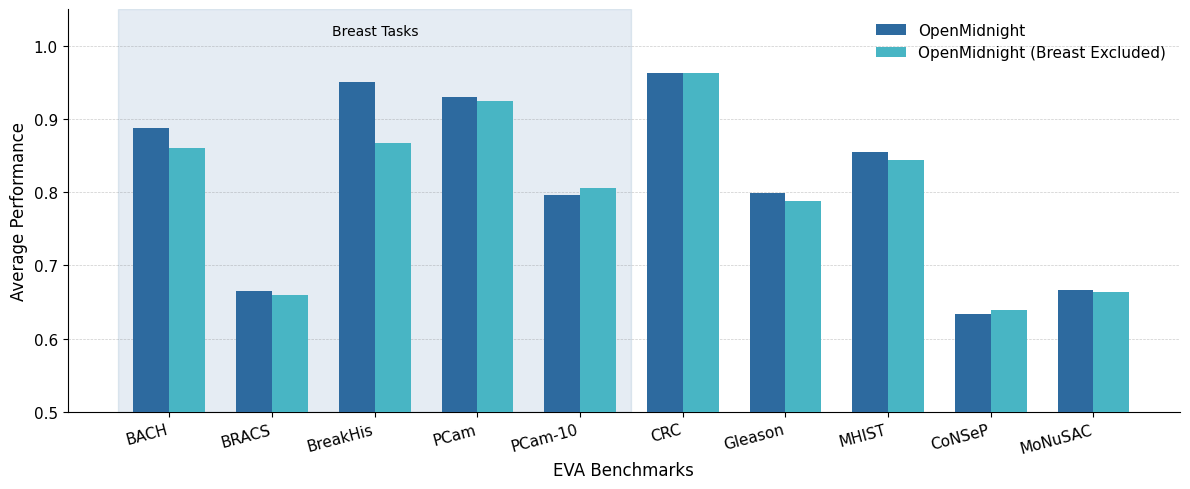

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load data ===
retrain_path = '/data/ratna/OM_retrain_3e-4/eval_results/ckpt_87500_to_137500/fast_eval_20260518_182336/summary.tsv'
no_breast_path = '/data/ratna/breast_exclusion/no_breast_output/eval_results/ckpt_87500_to_137500/fast_eval_20260518_181732/summary.tsv'

retrain_df = pd.read_csv(retrain_path, sep='\t')
no_breast_df = pd.read_csv(no_breast_path, sep='\t')

# === EDIT: set these to the correct column names after inspecting your tsv ===
# print(retrain_df.head()) to check
TASK_COL   = 'dataset'    # column with task/dataset name
METRIC_COL = 'metric_mean'  # column with performance value

# Filter to EVA tasks of interest
# Reordered: breast tasks first, then non-breast
TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10', 'crc', 'gleason', 'mhist', 'consep', 'monusac']
BREAST_TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10']

# Cleaner x-axis labels
TASK_LABELS = ['BACH', 'BRACS', 'BreakHis', 'PCam', 'PCam-10', 'CRC', 'Gleason', 'MHIST', 'CoNSeP', 'MoNuSAC']


retrain_scores   = retrain_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values
no_breast_scores = no_breast_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values

# --- Colors ---
COLOR_RETRAIN   = '#2D6A9F'  # cobalt
COLOR_NO_BREAST = '#48B5C4'  # cyan

# --- Plot ---
x = np.arange(len(TASKS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(x - width/2, retrain_scores,   width, label='OpenMidnight', color=COLOR_RETRAIN, zorder=3)
bars2 = ax.bar(x + width/2, no_breast_scores, width, label='OpenMidnight (Breast Excluded)', color=COLOR_NO_BREAST, zorder=3)

# --- Highlight breast task region ---
breast_indices = [TASKS.index(t) for t in BREAST_TASKS]
x_min = min(breast_indices) - 0.5
x_max = max(breast_indices) + 0.5

ax.axvspan(x_min, x_max, alpha=0.12, color=COLOR_RETRAIN, zorder=0)
# ax.text((x_min + x_max) / 2, 1.01,
#         'Breast Tasks', ha='center', va='bottom', fontsize=10,
#         color=COLOR_RETRAIN, fontstyle='italic')

ax.text((x_min + x_max) / 2, 1.01,
        'Breast Tasks', ha='center', va='bottom', fontsize=10,
        color='black')

# --- Axes & style ---
ax.set_xticks(x)
ax.set_xticklabels(TASK_LABELS, fontsize=11, rotation=15, ha='right')
ax.set_ylabel('Average Performance', fontsize=12)
ax.set_xlabel('EVA Benchmarks', fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.tick_params(axis='y', labelsize=11)

# Minimal grid
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray', zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Remove top/right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
ax.legend(fontsize=11, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('breast_exclusion.png', dpi=300, bbox_inches='tight')
plt.show()

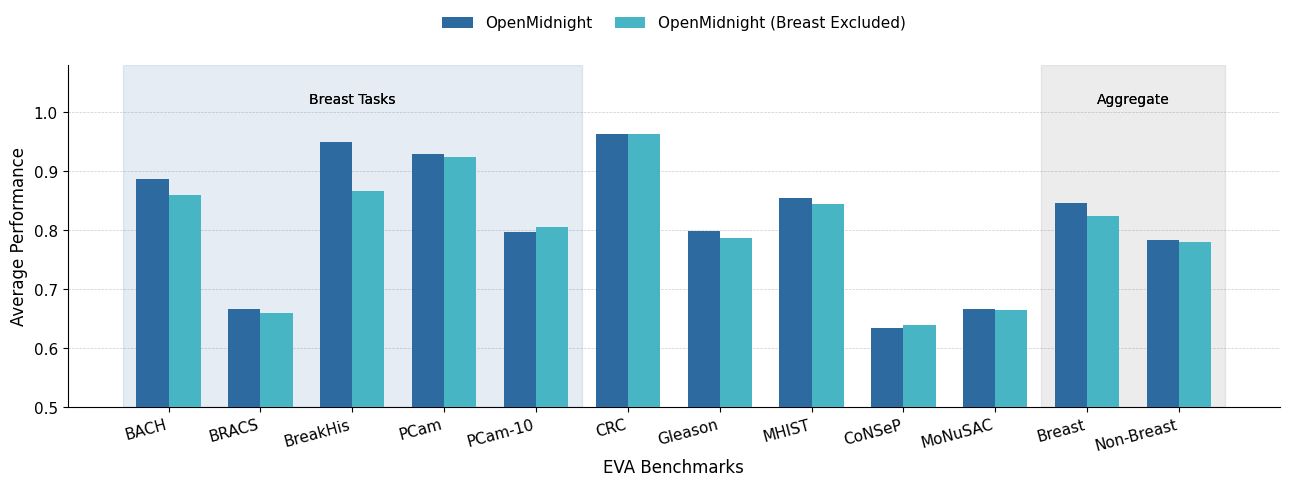

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# === Load data ===
retrain_path = '/data/ratna/OM_retrain_3e-4/eval_results/ckpt_87500_to_137500/fast_eval_20260518_182336/summary.tsv'
no_breast_path = '/data/ratna/breast_exclusion/no_breast_output/eval_results/ckpt_87500_to_137500/fast_eval_20260518_181732/summary.tsv'

retrain_df = pd.read_csv(retrain_path, sep='\t')
no_breast_df = pd.read_csv(no_breast_path, sep='\t')

TASK_COL   = 'dataset'
METRIC_COL = 'metric_mean'

TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10', 'crc', 'gleason', 'mhist', 'consep', 'monusac']
BREAST_TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10']
NON_BREAST_TASKS = ['crc', 'gleason', 'mhist', 'consep', 'monusac']

TASK_LABELS = ['BACH', 'BRACS', 'BreakHis', 'PCam', 'PCam-10', 'CRC', 'Gleason', 'MHIST', 'CoNSeP', 'MoNuSAC']

retrain_scores   = retrain_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values
no_breast_scores = no_breast_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values

retrain_breast_avg   = retrain_df.set_index(TASK_COL)[METRIC_COL].reindex(BREAST_TASKS).mean()
no_breast_breast_avg = no_breast_df.set_index(TASK_COL)[METRIC_COL].reindex(BREAST_TASKS).mean()
retrain_nonbreast_avg   = retrain_df.set_index(TASK_COL)[METRIC_COL].reindex(NON_BREAST_TASKS).mean()
no_breast_nonbreast_avg = no_breast_df.set_index(TASK_COL)[METRIC_COL].reindex(NON_BREAST_TASKS).mean()

COLOR_RETRAIN   = '#2D6A9F'
COLOR_NO_BREAST = '#48B5C4'

# --- Combine, no gap ---
all_labels = TASK_LABELS + ['Breast', 'Non-Breast']
all_retrain = np.concatenate([retrain_scores, [retrain_breast_avg, retrain_nonbreast_avg]])
all_no_breast = np.concatenate([no_breast_scores, [no_breast_breast_avg, no_breast_nonbreast_avg]])

n_total = len(all_labels)
x = np.arange(n_total)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(x - width/2, all_retrain,   width, label='OpenMidnight', color=COLOR_RETRAIN, zorder=3)
ax.bar(x + width/2, all_no_breast, width, label='OpenMidnight (Breast Excluded)', color=COLOR_NO_BREAST, zorder=3)

# --- Breast task highlight (original) ---
breast_indices = [TASKS.index(t) for t in BREAST_TASKS]
bx_min = min(breast_indices) - 0.5
bx_max = max(breast_indices) + 0.5
ax.axvspan(bx_min, bx_max, alpha=0.12, color=COLOR_RETRAIN, zorder=0)
ax.text((bx_min + bx_max) / 2, 1.01, 'Breast Tasks', ha='center', va='bottom', fontsize=10, color='black')

# --- Summary region highlight (neutral gray, distinguishes from raw tasks) ---
sx_min = len(TASKS) - 0.5
sx_max = n_total - 0.5
ax.axvspan(sx_min, sx_max, alpha=0.15, color='gray', zorder=0)
ax.text((sx_min + sx_max) / 2, 1.01, 'Aggregate', ha='center', va='bottom', fontsize=10, color='black')

# --- Axes & style ---
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=11, rotation=15, ha='right')


ax.set_ylabel('Average Performance', fontsize=12)
ax.set_xlabel('EVA Benchmarks', fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.tick_params(axis='y', labelsize=11)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray', zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# --- Legend: move above the plot, horizontal ---
ax.legend(
    fontsize=11, frameon=False,
    loc='lower center', bbox_to_anchor=(0.5, 1.06),
    ncol=2, columnspacing=1.5
)

# --- Region labels: nudge down slightly since legend now lives above them ---
ax.text((bx_min + bx_max) / 2, 1.01, 'Breast Tasks', ha='center', va='bottom', fontsize=10, color='black')
ax.text((sx_min + sx_max) / 2, 1.01, 'Aggregate', ha='center', va='bottom', fontsize=10, color='black')

# You'll likely need a bit more headroom for the legend + labels:
ax.set_ylim(0.5, 1.08)

plt.tight_layout()
plt.savefig('breast_exclusion_agg.png', dpi=300, bbox_inches='tight')
plt.show()

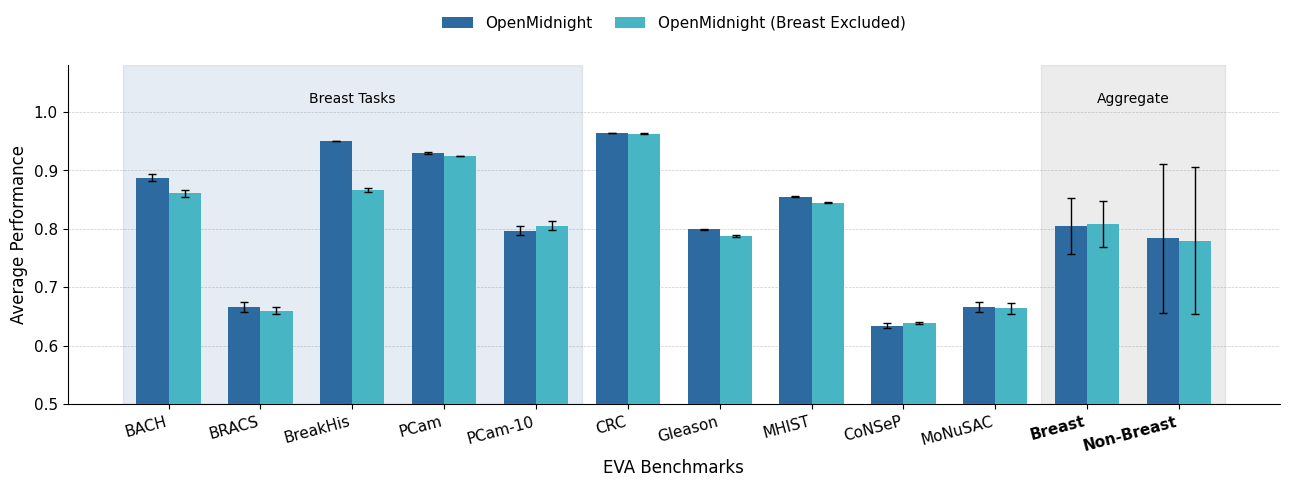

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# === Load data ===
retrain_path = '/data/ratna/OM_retrain_3e-4/eval_results/ckpt_87500_to_137500/fast_eval_20260518_182336/summary.tsv'
no_breast_path = '/data/ratna/breast_exclusion/no_breast_output/eval_results/ckpt_87500_to_137500/fast_eval_20260518_181732/summary.tsv'

retrain_df = pd.read_csv(retrain_path, sep='\t')
no_breast_df = pd.read_csv(no_breast_path, sep='\t')

TASK_COL   = 'dataset'
METRIC_COL = 'metric_mean'
RUNS_COL   = 'runs'

TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10', 'crc', 'gleason', 'mhist', 'consep', 'monusac']
BREAST_TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10']
NON_BREAST_TASKS = ['crc', 'gleason', 'mhist', 'consep', 'monusac']
TASK_LABELS = ['BACH', 'BRACS', 'BreakHis', 'PCam', 'PCam-10', 'CRC', 'Gleason', 'MHIST', 'CoNSeP', 'MoNuSAC']

def parse_runs(runs_str):
    """Extract list of float values from 'run_1=0.86, run_2=0.85' style string."""
    return [float(v) for v in re.findall(r'run_\d+=([\d.]+)', runs_str)]

def get_task_std(df, task):
    row = df[df[TASK_COL] == task]
    if row.empty:
        return np.nan
    vals = parse_runs(row[RUNS_COL].values[0])
    return np.std(vals, ddof=1) if len(vals) > 1 else 0.0

def get_task_runs(df, task):
    row = df[df[TASK_COL] == task]
    return parse_runs(row[RUNS_COL].values[0]) if not row.empty else []

# --- Per-task means and stds ---
retrain_scores   = retrain_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values
no_breast_scores = no_breast_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values

retrain_stds   = np.array([get_task_std(retrain_df, t) for t in TASKS])
no_breast_stds = np.array([get_task_std(no_breast_df, t) for t in TASKS])

# --- Aggregate averages + std (pooling all individual runs across tasks in the group) ---
def pooled_runs(df, task_list):
    all_vals = []
    for t in task_list:
        all_vals.extend(get_task_runs(df, t))
    return all_vals

retrain_breast_runs    = pooled_runs(retrain_df, BREAST_TASKS)
no_breast_breast_runs  = pooled_runs(no_breast_df, BREAST_TASKS)
retrain_nonbreast_runs = pooled_runs(retrain_df, NON_BREAST_TASKS)
no_breast_nonbreast_runs = pooled_runs(no_breast_df, NON_BREAST_TASKS)

retrain_breast_avg   = np.mean(retrain_breast_runs)
no_breast_breast_avg = np.mean(no_breast_breast_runs)
retrain_nonbreast_avg   = np.mean(retrain_nonbreast_runs)
no_breast_nonbreast_avg = np.mean(no_breast_nonbreast_runs)

retrain_breast_std   = np.std(retrain_breast_runs, ddof=1)
no_breast_breast_std = np.std(no_breast_breast_runs, ddof=1)
retrain_nonbreast_std   = np.std(retrain_nonbreast_runs, ddof=1)
no_breast_nonbreast_std = np.std(no_breast_nonbreast_runs, ddof=1)

# --- Combine all values ---
all_labels = TASK_LABELS + ['Breast', 'Non-Breast']
all_retrain = np.concatenate([retrain_scores, [retrain_breast_avg, retrain_nonbreast_avg]])
all_no_breast = np.concatenate([no_breast_scores, [no_breast_breast_avg, no_breast_nonbreast_avg]])
all_retrain_std = np.concatenate([retrain_stds, [retrain_breast_std, retrain_nonbreast_std]])
all_no_breast_std = np.concatenate([no_breast_stds, [no_breast_breast_std, no_breast_nonbreast_std]])

COLOR_RETRAIN   = '#2D6A9F'
COLOR_NO_BREAST = '#48B5C4'

n_total = len(all_labels)
x = np.arange(n_total)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))

err_kwargs = dict(ecolor='black', elinewidth=1, capsize=3, capthick=1)

ax.bar(x - width/2, all_retrain,   width, yerr=all_retrain_std,   error_kw=err_kwargs,
       label='OpenMidnight', color=COLOR_RETRAIN, zorder=3)
ax.bar(x + width/2, all_no_breast, width, yerr=all_no_breast_std, error_kw=err_kwargs,
       label='OpenMidnight (Breast Excluded)', color=COLOR_NO_BREAST, zorder=3)

# --- Breast task highlight ---
breast_indices = [TASKS.index(t) for t in BREAST_TASKS]
bx_min = min(breast_indices) - 0.5
bx_max = max(breast_indices) + 0.5
ax.axvspan(bx_min, bx_max, alpha=0.12, color=COLOR_RETRAIN, zorder=0)
ax.text((bx_min + bx_max) / 2, 1.01, 'Breast Tasks', ha='center', va='bottom', fontsize=10, color='black')

# --- Aggregate region highlight ---
sx_min = len(TASKS) - 0.5
sx_max = n_total - 0.5
ax.axvspan(sx_min, sx_max, alpha=0.15, color='gray', zorder=0)
ax.text((sx_min + sx_max) / 2, 1.01, 'Aggregate', ha='center', va='bottom', fontsize=10, color='black')

# --- Axes & style ---
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=11, rotation=15, ha='right')
for tick_label, label in zip(ax.get_xticklabels(), all_labels):
    if label in ('Breast', 'Non-Breast'):
        tick_label.set_fontweight('bold')

ax.set_ylabel('Average Performance', fontsize=12)
ax.set_xlabel('EVA Benchmarks', fontsize=12)
ax.set_ylim(0.5, 1.08)
ax.tick_params(axis='y', labelsize=11)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray', zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=11, frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.06), ncol=2, columnspacing=1.5)

plt.tight_layout()
plt.savefig('breast_exclusion.png', dpi=300, bbox_inches='tight')
plt.show()

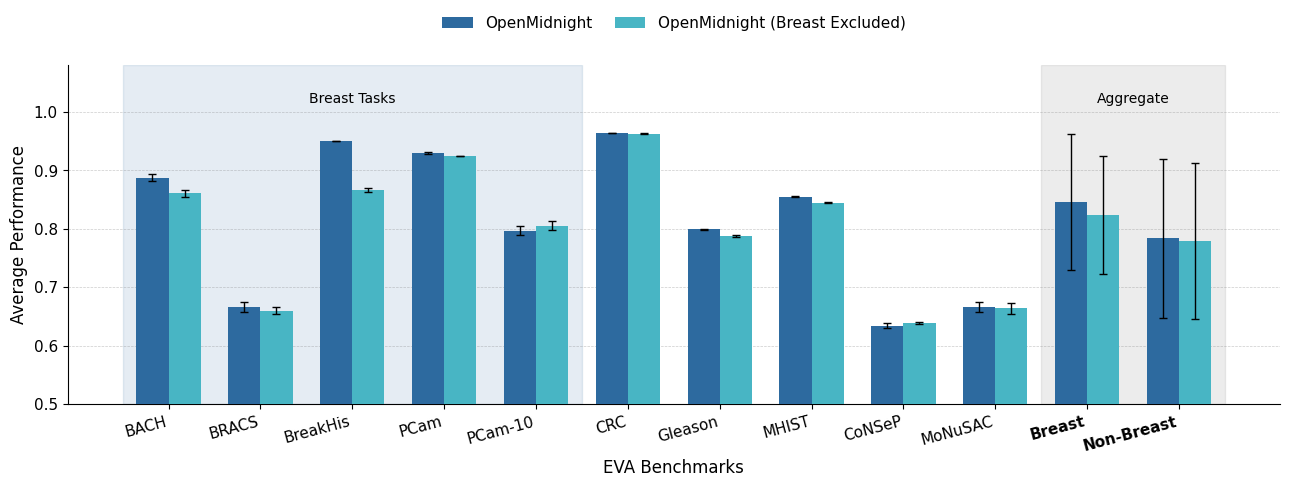

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# === Load data ===
retrain_path = '/data/ratna/OM_retrain_3e-4/eval_results/ckpt_87500_to_137500/fast_eval_20260518_182336/summary.tsv'
no_breast_path = '/data/ratna/breast_exclusion/no_breast_output/eval_results/ckpt_87500_to_137500/fast_eval_20260518_181732/summary.tsv'

retrain_df = pd.read_csv(retrain_path, sep='\t')
no_breast_df = pd.read_csv(no_breast_path, sep='\t')

TASK_COL   = 'dataset'
METRIC_COL = 'metric_mean'
RUNS_COL   = 'runs'

TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10', 'crc', 'gleason', 'mhist', 'consep', 'monusac']
BREAST_TASKS = ['bach', 'bracs', 'breakhist', 'pcam', 'pcam_10']
NON_BREAST_TASKS = ['crc', 'gleason', 'mhist', 'consep', 'monusac']
TASK_LABELS = ['BACH', 'BRACS', 'BreakHis', 'PCam', 'PCam-10', 'CRC', 'Gleason', 'MHIST', 'CoNSeP', 'MoNuSAC']

def parse_runs(runs_str):
    return [float(v) for v in re.findall(r'run_\d+=([\d.]+)', runs_str)]

def get_task_std(df, task):
    row = df[df[TASK_COL] == task]
    if row.empty:
        return np.nan
    vals = parse_runs(row[RUNS_COL].values[0])
    return np.std(vals, ddof=1) if len(vals) > 1 else 0.0

# --- Per-task means and stds (run-to-run noise, valid as before) ---
retrain_scores   = retrain_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values
no_breast_scores = no_breast_df.set_index(TASK_COL)[METRIC_COL].reindex(TASKS).values

retrain_stds   = np.array([get_task_std(retrain_df, t) for t in TASKS])
no_breast_stds = np.array([get_task_std(no_breast_df, t) for t in TASKS])

# === FIX: aggregate std computed across per-task MEANS, not pooled raw runs ===
def get_task_means(df, task_list):
    return df.set_index(TASK_COL)[METRIC_COL].reindex(task_list).values

retrain_breast_means    = get_task_means(retrain_df, BREAST_TASKS)
no_breast_breast_means  = get_task_means(no_breast_df, BREAST_TASKS)
retrain_nonbreast_means   = get_task_means(retrain_df, NON_BREAST_TASKS)
no_breast_nonbreast_means = get_task_means(no_breast_df, NON_BREAST_TASKS)

retrain_breast_avg   = np.mean(retrain_breast_means)
no_breast_breast_avg = np.mean(no_breast_breast_means)
retrain_nonbreast_avg   = np.mean(retrain_nonbreast_means)
no_breast_nonbreast_avg = np.mean(no_breast_nonbreast_means)

retrain_breast_std   = np.std(retrain_breast_means, ddof=1)
no_breast_breast_std = np.std(no_breast_breast_means, ddof=1)
retrain_nonbreast_std   = np.std(retrain_nonbreast_means, ddof=1)
no_breast_nonbreast_std = np.std(no_breast_nonbreast_means, ddof=1)

# --- Combine all values ---
all_labels = TASK_LABELS + ['Breast', 'Non-Breast']
all_retrain = np.concatenate([retrain_scores, [retrain_breast_avg, retrain_nonbreast_avg]])
all_no_breast = np.concatenate([no_breast_scores, [no_breast_breast_avg, no_breast_nonbreast_avg]])
all_retrain_std = np.concatenate([retrain_stds, [retrain_breast_std, retrain_nonbreast_std]])
all_no_breast_std = np.concatenate([no_breast_stds, [no_breast_breast_std, no_breast_nonbreast_std]])

COLOR_RETRAIN   = '#2D6A9F'
COLOR_NO_BREAST = '#48B5C4'

n_total = len(all_labels)
x = np.arange(n_total)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))

err_kwargs = dict(ecolor='black', elinewidth=1, capsize=3, capthick=1)

ax.bar(x - width/2, all_retrain,   width, yerr=all_retrain_std,   error_kw=err_kwargs,
       label='OpenMidnight', color=COLOR_RETRAIN, zorder=3)
ax.bar(x + width/2, all_no_breast, width, yerr=all_no_breast_std, error_kw=err_kwargs,
       label='OpenMidnight (Breast Excluded)', color=COLOR_NO_BREAST, zorder=3)

# --- Breast task highlight ---
breast_indices = [TASKS.index(t) for t in BREAST_TASKS]
bx_min = min(breast_indices) - 0.5
bx_max = max(breast_indices) + 0.5
ax.axvspan(bx_min, bx_max, alpha=0.12, color=COLOR_RETRAIN, zorder=0)
ax.text((bx_min + bx_max) / 2, 1.01, 'Breast Tasks', ha='center', va='bottom', fontsize=10, color='black')

# --- Aggregate region highlight ---
sx_min = len(TASKS) - 0.5
sx_max = n_total - 0.5
ax.axvspan(sx_min, sx_max, alpha=0.15, color='gray', zorder=0)
ax.text((sx_min + sx_max) / 2, 1.01, 'Aggregate', ha='center', va='bottom', fontsize=10, color='black')

# --- Axes & style ---
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=11, rotation=15, ha='right')
for tick_label, label in zip(ax.get_xticklabels(), all_labels):
    if label in ('Breast', 'Non-Breast'):
        tick_label.set_fontweight('bold')

ax.set_ylabel('Average Performance', fontsize=12)
ax.set_xlabel('EVA Benchmarks', fontsize=12)
ax.set_ylim(0.5, 1.08)
ax.tick_params(axis='y', labelsize=11)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.4, color='gray', zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(fontsize=11, frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.06), ncol=2, columnspacing=1.5)

plt.tight_layout()
plt.savefig('breast_exclusion.png', dpi=300, bbox_inches='tight')
plt.show()